6/22/2026 notes

# kNN In-Context Example Selection

Implementation of **Algorithm 1** from:
> Liu et al. *What Makes Good In-Context Examples for GPT-3?* ACL 2021

## Key Idea
Standard few-shot prompting picks **random** examples from the training set. This algorithm instead picks the **k nearest neighbors** of the test prompt (by embedding similarity), so the in-context examples are semantically relevant.

### Algorithm 1 — kNN In-context Example Selection
**Given:** test prompt $x_{\text{test}}$, training set $\mathcal{D}_{tr} = \{(x_i, y_i)\}_{i=1}^N$, sentence encoder $\mu_\theta(\cdot)$, number of examples $k$

1. $v_{\text{test}} = \mu_\theta(x_{\text{test}})$
2. **for each** $x_i \in \mathcal{D}_{tr}$:
   - $v_i = \mu_\theta(x_i)$
   - $s_i = \|v_{\text{test}} - v_i\|_2$ (or cosine similarity)
3. Select $k$ largest similarities $s_i$ → indices $\{\sigma(1), \ldots, \sigma(k)\}$
4. $C = [x_{\sigma(1)}; y_{\sigma(1)}; \ldots; x_{\sigma(k)}; y_{\sigma(k)}]$
5. $y_{\text{test}} = \text{LLM}([C; x_{\text{test}}])$

### Setup
| Component | Choice | Reason |
|---|---|---|
| LLM | `HuggingFaceTB/SmolLM2-135M-Instruct` | Smallest capable instruction-following model (135M params) |
| Sentence Encoder | `sentence-transformers/all-MiniLM-L6-v2` | Fast, lightweight, strong embedding quality |
| Dataset | `stanfordnlp/sst2` (GLUE SST-2) | Binary sentiment classification — simple, clear labels |

In [17]:
# Install dependencies if needed
# %pip install -q transformers datasets sentence-transformers torch accelerate

In [ ]:
import torch
import numpy as np
import random
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics.pairwise import cosine_similarity

# set seeds (THIS IS CRITICAL, ML MODELS ARE NOT DETERMINISTIC)
SEED = 9
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## Step 1 — Load Dataset (SST-2)

SST-2 is binary movie-review sentiment: `0 = negative`, `1 = positive`.
We use a small slice of the training set as our retrieval pool $\mathcal{D}_{tr}$.

In [19]:
dataset = load_dataset("stanfordnlp/sst2")

# Use 500 training examples as the retrieval pool
N_TRAIN = 500
N_TEST  = 50

train_split = dataset["train"].shuffle(seed=SEED).select(range(N_TRAIN))
test_split  = dataset["validation"].shuffle(seed=SEED).select(range(N_TEST))

LABEL_MAP = {0: "negative", 1: "positive"}

train_texts  = [ex["sentence"] for ex in train_split]
train_labels = [LABEL_MAP[ex["label"]] for ex in train_split]
test_texts   = [ex["sentence"] for ex in test_split]
test_labels  = [LABEL_MAP[ex["label"]] for ex in test_split]

print(f"Training pool : {len(train_texts)} examples")
print(f"Test set      : {len(test_texts)} examples")
print(f"\nSample training example:")
print(f"  Text  : {train_texts[3]}")
print(f"  Label : {train_labels[3]}")

Training pool : 500 examples
Test set      : 50 examples

Sample training example:
  Text  : just one of those underrated professionals who deserve but rarely receive it 
  Label : positive


## Step 2 — Sentence Encoder $\mu_\theta(\cdot)$

We pre-encode all training examples once.
At inference time we only need to encode the test prompt and do a similarity lookup.

In [20]:
print("Loading sentence encoder...")
encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# Pre-encode entire training pool
print("Encoding training pool...")
train_embeddings = encoder.encode(train_texts, batch_size=64, show_progress_bar=True, normalize_embeddings=True)

print(f"\nEmbedding matrix shape: {train_embeddings.shape}  (N_train × d)")

Loading sentence encoder...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Encoding training pool...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]


Embedding matrix shape: (500, 384)  (N_train × d)


## Step 3 — Load SmolLM2-135M-Instruct

SmolLM2-135M-Instruct is HuggingFace's smallest instruction-tuned model (~135M parameters).

In [21]:
MODEL_ID = "HuggingFaceTB/SmolLM2-135M-Instruct"

print(f"Loading {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
# model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32) # [transformers] `torch_dtype` is deprecated! Use `dtype` instead!
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32)
model = model.to(DEVICE)
model.eval()

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model loaded — {n_params:.0f}M parameters")

Loading HuggingFaceTB/SmolLM2-135M-Instruct...


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Model loaded — 135M parameters


## Step 4 — Core Algorithm Implementation

Two functions:
- `select_knn_examples()` — nearest-neighbor retrieval
- `build_prompt()` — format context $C$ + test prompt
- `predict()` — run LLM

In [ ]:
def select_knn_examples(x_test: str, k: int) -> list[tuple[str, str]]:
    """
    Returns k (text, label) pairs whose embeddings are closest to x_test.
    """
    # encode test prompt
    v_test = encoder.encode([x_test], normalize_embeddings=True)  # shape (1, d)

    # cosine similarity  (normalized vecs → dot product = cosine sim; higher = more similar)
    similarities = cosine_similarity(v_test, train_embeddings)[0]  # shape (N,)

    # select top-k indices in descending order
    top_k_indices = np.argsort(similarities)[::-1][:k]

    return [(train_texts[i], train_labels[i]) for i in top_k_indices]


def select_random_examples(x_test: str, k: int) -> list[tuple[str, str]]:
    """Baseline: random k examples (standard few-shot)."""
    indices = random.sample(range(len(train_texts)), k)
    return [(train_texts[i], train_labels[i]) for i in indices]


def build_prompt(examples: list[tuple[str, str]], x_test: str) -> str:
    """
    build context C concatenated with test prompt.
    Format:  Review: <text>\nSentiment: <label>\n\n ... \nReview: <test>\nSentiment:
    """
    lines = []
    for text, label in examples:
        lines.append(f"Review: {text}\nSentiment: {label}")
    lines.append(f"Review: {x_test}\nSentiment:")
    return "\n\n".join(lines)


def predict(prompt: str, max_new_tokens: int = 5) -> str:
    """
    Returns the first token(s) generated after the prompt.
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad(): # set to .no_grad() to set to evaluation mode (and not waste time backpropogating the gradient)
        output_ids = model.generate( # .generate tells model to generate new tokens
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,          # greedy — deterministic
            pad_token_id=tokenizer.eos_token_id,
        )
    # Decode only the newly generated tokens
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()


def parse_label(raw: str) -> str:
    """Map raw generation to 'positive' / 'negative' / 'unknown'."""
    if "positive" in raw:
        return "positive"
    elif "negative" in raw:
        return "negative"
    return "unknown"


print("Functions defined.")

Functions defined.


## Step 5 — Walkthrough on a Single Example

Trace through Algorithm 1 step-by-step to build intuition.

In [23]:
K = 8  # number of in-context examples

demo_text  = test_texts[0]
demo_label = test_labels[0]

print("=" * 60)
print(f"TEST PROMPT (x_test):\n  {demo_text}")
print(f"TRUE LABEL            : {demo_label}")
print("=" * 60)

# --- kNN selection ---
knn_examples = select_knn_examples(demo_text, k=K)
print(f"\nTop-{K} nearest neighbors retrieved:")
for i, (txt, lbl) in enumerate(knn_examples, 1):
    print(f"  [{i}] ({lbl}) {txt[:80]}...")

# --- Build prompt ---
knn_prompt = build_prompt(knn_examples, demo_text)
print(f"\n--- Prompt sent to LLM ---\n{knn_prompt}\n--- end of prompt ---")

# --- LLM prediction ---
raw_output = predict(knn_prompt)
predicted  = parse_label(raw_output)

print(f"\nRaw LLM output : '{raw_output}'")
print(f"Parsed label   : {predicted}")
print(f"True label     : {demo_label}")
print(f"Correct?       : {'✓' if predicted == demo_label else '✗'}")

TEST PROMPT (x_test):
  but the power of these ( subjects ) is obscured by the majority of the film that shows a stationary camera on a subject that could be mistaken for giving a public oration , rather than contributing to a film 's narrative . 
TRUE LABEL            : negative

Top-8 nearest neighbors retrieved:
  [1] (positive) the unusual power of thoughtful , subjective filmmaking ...
  [2] (negative) 's indicative of how uncompelling the movie is unless it happens to cover your p...
  [3] (negative) the whole film has this sneaky feel to it -- as if the director is trying to dup...
  [4] (positive) not all of the stories work and the ones that do are thin and scattered , but th...
  [5] (negative) purports to be a hollywood satire but winds up as the kind of film that should b...
  [6] (positive) hold dear about cinema ...
  [7] (positive) of oral storytelling frozen onto film ...
  [8] (positive) a properly spooky film about the power of spirits to influence us whether we bel..

## Step 6 — Evaluation: kNN-ICL vs Random-ICL

Run both selection strategies over the test set and compare accuracy.

In [24]:
knn_preds    = []
random_preds = []

print(f"Running inference on {N_TEST} test examples (k={K})...\n")
# print(f"{'#':<4} {'True':<10} {'kNN pred':<12} {'Rand pred':<12} {'kNN ✓':<6} {'Rand ✓'}")
# print("-" * 60)

for i, (x_test, y_true) in enumerate(zip(test_texts, test_labels)):
    # kNN selection
    knn_ex     = select_knn_examples(x_test, k=K)
    knn_prompt = build_prompt(knn_ex, x_test)
    knn_raw    = predict(knn_prompt)
    knn_pred   = parse_label(knn_raw)

    # Random selection
    rand_ex     = select_random_examples(x_test, k=K)
    rand_prompt = build_prompt(rand_ex, x_test)
    rand_raw    = predict(rand_prompt)
    rand_pred   = parse_label(rand_raw)

    knn_preds.append(knn_pred)
    random_preds.append(rand_pred)

    knn_ok  = "✓" if knn_pred  == y_true else "✗"
    rand_ok = "✓" if rand_pred == y_true else "✗"
    # print(f"{i:<4} {y_true:<10} {knn_pred:<12} {rand_pred:<12} {knn_ok:<6} {rand_ok}")

# print("-" * 60)

Running inference on 50 test examples (k=8)...



## Step 7 — Results Summary

In [25]:
def accuracy(preds, labels):
    valid = [(p, l) for p, l in zip(preds, labels) if p != "unknown"]
    if not valid:
        return 0.0
    return sum(p == l for p, l in valid) / len(valid)

knn_acc  = accuracy(knn_preds, test_labels)
rand_acc = accuracy(random_preds, test_labels)

knn_unknowns  = knn_preds.count("unknown")
rand_unknowns = random_preds.count("unknown")

print("=" * 50)
print(f"  Model  : {MODEL_ID}")
print(f"  k      : {K} in-context examples")
print(f"  N_test : {N_TEST}")
print("=" * 50)
print(f"  kNN-ICL  accuracy : {knn_acc:.1%}  (unknowns: {knn_unknowns})")
print(f"  Random   accuracy : {rand_acc:.1%}  (unknowns: {rand_unknowns})")
print("=" * 50)

delta = knn_acc - rand_acc
direction = "better" if delta >= 0 else "worse"
print(f"\n  kNN is {abs(delta):.1%} {direction} than random selection.")

  Model  : HuggingFaceTB/SmolLM2-135M-Instruct
  k      : 8 in-context examples
  N_test : 50
  kNN-ICL  accuracy : 74.0%  (unknowns: 0)
  Random   accuracy : 72.0%  (unknowns: 0)

  kNN is 2.0% better than random selection.


---

# Algorithm 2 — Prompt Selection via Perplexity

> Sorensen et al. *Demystifying prompts in language models via perplexity estimation.* arXiv 2022

## Key Idea
The wording of the prompt template (independent of which examples you pick) dramatically affects accuracy. The paper shows a strong negative correlation between **prompt perplexity** and **accuracy**: prompts that feel more "natural" to the model (lower perplexity) tend to yield better predictions.

### Algorithm Steps
1. Obtain a small set of **manually created** prompt templates for the task
2. **Expand** the set via automatic paraphrasing with an LM and/or backtranslation
3. **Rank** all candidate templates by their perplexity under the LLM
4. **Choose** the $k$ lowest-perplexity templates for inference

### Perplexity as a proxy for prompt quality
For a template $T$ and training examples $\{(x_i, y_i)\}$:

$$\text{PPL}(T) = \exp\!\left( -\frac{1}{N} \sum_{i=1}^{N} \log p_\theta\bigl(T(x_i, y_i)\bigr) \right)$$

Lower perplexity → the model assigns higher probability to the filled-in template → the prompt aligns better with the model's pretraining distribution → better downstream accuracy.

## Step 1 — Seed Prompt Templates (Manual)

We write a small set of prompt templates by hand. Each template is a Python callable that formats one labelled example `(text, label)` into a string. The `{query}` slot holds the test input (no label).

In [26]:
# ── Step 1: Seed templates ──────────────────────────
# Each entry is (name, filled_template_fn, query_template_fn)
# filled_template_fn(text, label) → complete labeled string for PPL scoring
# query_template_fn(text)         → prompt suffix for inference (no label)

seed_templates = [
    (
        "review/sentiment",
        lambda t, l: f"Review: {t}\nSentiment: {l}",
        lambda t:    f"Review: {t}\nSentiment:",
    ),
    (
        "movie/opinion",
        lambda t, l: f"Movie review: {t}\nOpinion: {l}",
        lambda t:    f"Movie review: {t}\nOpinion:",
    ),
    (
        "text/label",
        lambda t, l: f"Text: {t}\nLabel: {l}",
        lambda t:    f"Text: {t}\nLabel:",
    ),
    (
        "critic/verdict",
        lambda t, l: f"Critic: {t}\nVerdict: {l}",
        lambda t:    f"Critic: {t}\nVerdict:",
    ),
    (
        "passage/tone",
        lambda t, l: f"Passage: {t}\nTone: {l}",
        lambda t:    f"Passage: {t}\nTone:",
    ),
]

print(f"Seed templates defined: {len(seed_templates)}")
for name, fn, _ in seed_templates:
    print(f"  [{name}]  e.g. → {fn('great film', 'positive')[:60]}")

Seed templates defined: 5
  [review/sentiment]  e.g. → Review: great film
Sentiment: positive
  [movie/opinion]  e.g. → Movie review: great film
Opinion: positive
  [text/label]  e.g. → Text: great film
Label: positive
  [critic/verdict]  e.g. → Critic: great film
Verdict: positive
  [passage/tone]  e.g. → Passage: great film
Tone: positive


## Step 2 — Expand via Automatic Paraphrasing

We prompt the LLM itself to paraphrase each seed template into alternative wordings, then add them to the candidate pool. This mirrors the paper's use of GPT-3 or backtranslation for expansion.

In [27]:
def generate_paraphrase(filled_example: str, query_example: str, template_name: str) -> tuple[str, str] | None:
    """
    Ask the LLM to rephrase a seed template into a new wording.
    Returns (new_filled_fn_str, new_query_fn_str) by parsing generated output,
    or None if parsing fails.
    """
    # Extract the structural prefix (everything before the actual sentence text)
    # by looking at the filled example with a known short text
    probe_text, probe_label = "the film was great", "positive"
    probe_filled = filled_example(probe_text, probe_label)
    probe_query  = query_example(probe_text)

    paraphrase_prompt = (
        f"Rewrite the following text classification template using different words. "
        f"Keep the {{TEXT}} and {{LABEL}} placeholders in exactly the same positions.\n\n"
        f"Original filled:  {probe_filled}\n"
        f"Original query:   {probe_query}\n\n"
        f"Rewritten filled:"
    )
    inputs = tokenizer(paraphrase_prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=True,
            temperature=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = out[0][inputs["input_ids"].shape[1]:]
    generated  = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    # Parse: expect "X: {TEXT}\nY: {LABEL}" pattern from the first generated line
    first_line = generated.split("\n")[0].strip()
    if ":" not in first_line:
        return None
    prefix, _ = first_line.split(":", 1)
    prefix = prefix.strip()

    # Try to find a second key word for the label line from the generated text
    lines = generated.split("\n")
    label_prefix = None
    for ln in lines[1:]:
        if ":" in ln:
            label_prefix = ln.split(":")[0].strip()
            break

    if not label_prefix or label_prefix.lower() == prefix.lower():
        return None

    new_name         = f"{template_name}__para"
    new_filled_fn    = (lambda p, lp: (lambda t, l: f"{p}: {t}\n{lp}: {l}"))(prefix, label_prefix)
    new_query_fn     = (lambda p, lp: (lambda t:    f"{p}: {t}\n{lp}:"))(prefix, label_prefix)
    return new_name, new_filled_fn, new_query_fn


# ── Expand seed pool with paraphrases ────────────────────────────────────────
all_templates = list(seed_templates)  # start with seeds
print("Generating paraphrases for each seed template...\n")
for name, filled_fn, query_fn in seed_templates:
    result = generate_paraphrase(filled_fn, query_fn, name)
    if result is not None:
        new_name, new_filled, new_query = result
        all_templates.append((new_name, new_filled, new_query))
        probe = new_filled("great film", "positive")
        print(f"  ✓ [{new_name}]  e.g. → {probe[:60]}")
    else:
        print(f"  ✗ [{name}]  paraphrase parsing failed — skipping")

print(f"\nCandidate pool size: {len(all_templates)} templates ({len(seed_templates)} seed + {len(all_templates)-len(seed_templates)} paraphrases)")

Generating paraphrases for each seed template...

  ✓ [review/sentiment__para]  e.g. → Review: great film
Sentiment: positive
  ✗ [movie/opinion]  paraphrase parsing failed — skipping
  ✗ [text/label]  paraphrase parsing failed — skipping
  ✗ [critic/verdict]  paraphrase parsing failed — skipping
  ✓ [passage/tone__para]  e.g. → Passage: great film
Tone: positive

Candidate pool size: 7 templates (5 seed + 2 paraphrases)


## Step 3 — Rank Templates by Perplexity

For each candidate template we compute its **average perplexity** over a sample of training examples. Perplexity is computed as $\exp(\mathcal{L})$ where $\mathcal{L}$ is the cross-entropy loss the LLM assigns to the fully-filled string.

In [28]:
def compute_perplexity(text: str) -> float:
    """Cross-entropy loss → perplexity for a single string."""
    enc = tokenizer(text, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        loss = model(**enc, labels=enc["input_ids"]).loss
    return torch.exp(loss).item()


def template_perplexity(filled_fn, n_samples: int = 20) -> float:
    """
    Average perplexity of filled_fn(text, label) across n_samples training examples.
    """
    ppls = []
    for text, label in zip(train_texts[:n_samples], train_labels[:n_samples]):
        ppls.append(compute_perplexity(filled_fn(text, label)))
    return float(np.mean(ppls))


def predict_by_likelihood(filled_fn, x_test: str) -> str:
    """
    Zero-shot classification via likelihood comparison (no in-context examples,
    no free-form generation): fill the template with EACH candidate label and
    pick whichever the LLM finds more probable (lower perplexity = higher
    likelihood). A 135M model rarely emits "positive"/"negative" on its own
    when asked to continue an unfamiliar zero-shot template — but it can still
    tell us which of the two candidate completions it finds more natural.
    """
    ppl_pos = compute_perplexity(filled_fn(x_test, "positive"))
    ppl_neg = compute_perplexity(filled_fn(x_test, "negative"))
    return "positive" if ppl_pos < ppl_neg else "negative"


# ── Rank all candidates by ascending perplexity ──────────────────────────────
print("Computing perplexity for each template (this takes ~1–2 min)...\n")
ranked = []
for name, filled_fn, query_fn in all_templates:
    ppl = template_perplexity(filled_fn)
    ranked.append((ppl, name, filled_fn, query_fn))
    print(f"  PPL={ppl:8.2f}  [{name}]")

ranked.sort(key=lambda x: x[0])  # ascending = lowest PPL first

print("\n─── Ranked (best → worst) ───────────────────────────────")
print(f"{'Rank':<6} {'PPL':>10}  Template")
for rank, (ppl, name, _, _) in enumerate(ranked, 1):
    marker = " ←── best" if rank == 1 else ""
    print(f"  {rank:<4} {ppl:>10.2f}  {name}{marker}")

Computing perplexity for each template (this takes ~1–2 min)...

  PPL=  214.57  [review/sentiment]
  PPL=  407.17  [movie/opinion]
  PPL=  767.27  [text/label]
  PPL=  310.04  [critic/verdict]
  PPL=  289.29  [passage/tone]
  PPL=  214.57  [review/sentiment__para]
  PPL=  289.29  [passage/tone__para]

─── Ranked (best → worst) ───────────────────────────────
Rank          PPL  Template
  1        214.57  review/sentiment ←── best
  2        214.57  review/sentiment__para
  3        289.29  passage/tone
  4        289.29  passage/tone__para
  5        310.04  critic/verdict
  6        407.17  movie/opinion
  7        767.27  text/label


## Step 4 — Inference with Lowest-Perplexity Template

We pick the single best template (lowest PPL) and run zero-shot inference — no in-context examples at all, just the template wording chosen by the perplexity criterion. We also try the **worst** template as a negative control to confirm the PPL signal is meaningful.

**A note on how we classify:** with zero in-context examples, a 135M model very often just continues the sentence (e.g. "Critic: ... \nVerdict:" → "...the movie") instead of ever emitting the word "positive" or "negative". Free-form generation + keyword search would then label everything "unknown". Instead we reuse the same perplexity machinery from Step 3: fill the template with **each** candidate label and ask the model which completion it finds more probable (`predict_by_likelihood`). This always returns a label, and it's the same likelihood-based reasoning the rest of Algorithm 2 already relies on.

In [29]:
# ── Choose best-k templates ───────────────────────────
best_ppl,  best_name,  best_filled,  best_query  = ranked[0]   # lowest PPL
worst_ppl, worst_name, worst_filled, worst_query = ranked[-1]  # highest PPL

print(f"Best  template : [{best_name}]   PPL={best_ppl:.2f}")
print(f"Worst template : [{worst_name}]  PPL={worst_ppl:.2f}\n")
print(f"Example prompt with best template:\n  {best_query(test_texts[0])}\n")

# ── Zero-shot inference with best and worst templates (likelihood-based) ────
best_ppl_preds  = []
worst_ppl_preds = []

print(f"{'#':<4} {'True':<10} {'best-PPL':<12} {'worst-PPL':<12} {'B✓':<4} {'W✓'}")
print("-" * 55)
for i, (x_test, y_true) in enumerate(zip(test_texts, test_labels)):
    b_pred = predict_by_likelihood(best_filled,  x_test)
    w_pred = predict_by_likelihood(worst_filled, x_test)
    best_ppl_preds.append(b_pred)
    worst_ppl_preds.append(w_pred)
    b_ok = "✓" if b_pred == y_true else "✗"
    w_ok = "✓" if w_pred == y_true else "✗"
    print(f"{i:<4} {y_true:<10} {b_pred:<12} {w_pred:<12} {b_ok:<4} {w_ok}")
print("-" * 55)

best_ppl_acc  = accuracy(best_ppl_preds,  test_labels)
worst_ppl_acc = accuracy(worst_ppl_preds, test_labels)
print(f"\nBest-PPL  template zero-shot accuracy : {best_ppl_acc:.1%}")
print(f"Worst-PPL template zero-shot accuracy : {worst_ppl_acc:.1%}")

Best  template : [review/sentiment]   PPL=214.57
Worst template : [text/label]  PPL=767.27

Example prompt with best template:
  Review: but the power of these ( subjects ) is obscured by the majority of the film that shows a stationary camera on a subject that could be mistaken for giving a public oration , rather than contributing to a film 's narrative . 
Sentiment:

#    True       best-PPL     worst-PPL    B✓   W✓
-------------------------------------------------------
0    negative   negative     negative     ✓    ✓
1    positive   positive     negative     ✓    ✗
2    positive   positive     negative     ✓    ✗
3    positive   negative     negative     ✗    ✗
4    positive   negative     negative     ✗    ✗
5    positive   positive     negative     ✓    ✗
6    positive   positive     negative     ✓    ✗
7    negative   negative     negative     ✓    ✓
8    negative   negative     negative     ✓    ✓
9    negative   negative     negative     ✓    ✓
10   positive   negative     ne

Computing per-template accuracy for scatter plot...

  PPL=  214.57  acc=76.0%  [review/sentiment]
  PPL=  214.57  acc=76.0%  [review/sentiment__para]
  PPL=  289.29  acc=78.0%  [passage/tone]
  PPL=  289.29  acc=78.0%  [passage/tone__para]
  PPL=  310.04  acc=52.0%  [critic/verdict]
  PPL=  407.17  acc=60.0%  [movie/opinion]
  PPL=  767.27  acc=52.0%  [text/label]


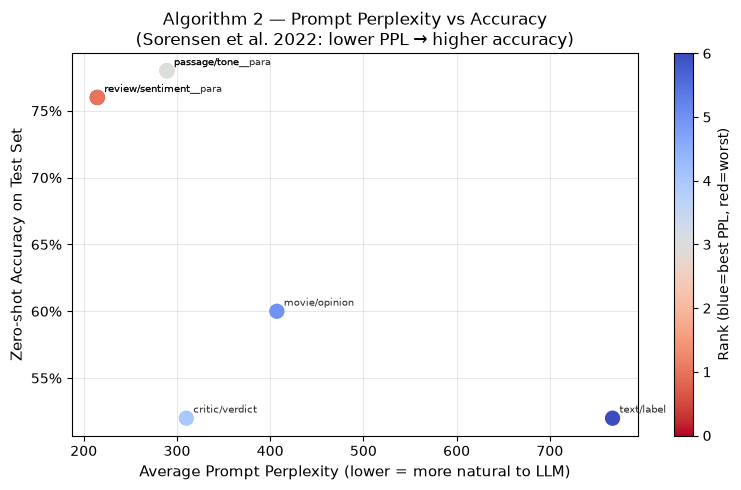


Pearson r (PPL vs accuracy) = -0.695  (negative — confirms paper!)


In [30]:
import matplotlib.pyplot as plt

# ── Replicate the paper's PPL vs Accuracy scatter ────────────────────────────
# Compute zero-shot accuracy for every template in the ranked list (likelihood-based)
print("Computing per-template accuracy for scatter plot...\n")
template_ppls   = []
template_accs   = []
template_names_ = []

for ppl, name, filled_fn, _ in ranked:
    preds = [predict_by_likelihood(filled_fn, x) for x in test_texts]
    acc   = accuracy(preds, test_labels)
    template_ppls.append(ppl)
    template_accs.append(acc)
    template_names_.append(name)
    print(f"  PPL={ppl:8.2f}  acc={acc:.1%}  [{name}]")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(template_ppls, template_accs, c=range(len(template_ppls)),
                     cmap="coolwarm_r", s=100, zorder=3)

for ppl, acc, name in zip(template_ppls, template_accs, template_names_):
    ax.annotate(name, (ppl, acc), textcoords="offset points",
                xytext=(5, 4), fontsize=7.5, alpha=0.85)

ax.set_xlabel("Average Prompt Perplexity (lower = more natural to LLM)", fontsize=11)
ax.set_ylabel("Zero-shot Accuracy on Test Set", fontsize=11)
ax.set_title("Algorithm 2 — Prompt Perplexity vs Accuracy\n"
             "(Sorensen et al. 2022: lower PPL → higher accuracy)", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label="Rank (blue=best PPL, red=worst)")
plt.tight_layout()
plt.show()

# Correlation coefficient
corr = np.corrcoef(template_ppls, template_accs)[0, 1]
print(f"\nPearson r (PPL vs accuracy) = {corr:.3f}  "
      f"({'negative — confirms paper!' if corr < 0 else 'positive'})")

## Final Comparison — All Algorithms

Side-by-side accuracy across every method covered in this notebook so far.

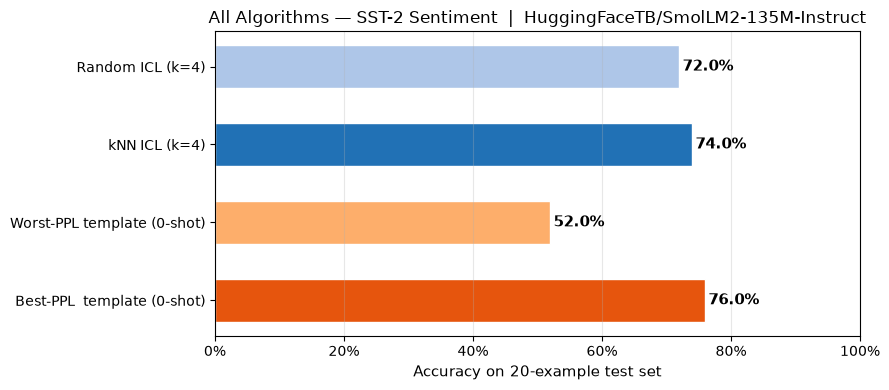


  Method                                        Acc  Notes
  Random ICL (k=4)                            72.0%  random examples, fixed template
  kNN ICL (k=4)                               74.0%  nearest-neighbour examples, fixed template
  Worst-PPL template (0-shot)                 52.0%  [text/label]  PPL=767.3
  Best-PPL  template (0-shot)                 76.0%  [review/sentiment]   PPL=214.6


In [31]:
results = [
    ("Random ICL (k=4)",          rand_acc,      "random examples, fixed template"),
    ("kNN ICL (k=4)",             knn_acc,       "nearest-neighbour examples, fixed template"),
    ("Worst-PPL template (0-shot)", worst_ppl_acc, f"[{worst_name}]  PPL={worst_ppl:.1f}"),
    ("Best-PPL  template (0-shot)", best_ppl_acc,  f"[{best_name}]   PPL={best_ppl:.1f}"),
]

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
labels = [r[0] for r in results]
accs   = [r[1] for r in results]
colors = ["#aec6e8", "#2171b5", "#fdae6b", "#e6550d"]
bars   = ax.barh(labels, accs, color=colors, edgecolor="white", height=0.55)

for bar, acc in zip(bars, accs):
    ax.text(acc + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{acc:.1%}", va="center", fontsize=11, fontweight="bold")

ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlabel("Accuracy on 20-example test set", fontsize=11)
ax.set_title(f"All Algorithms — SST-2 Sentiment  |  {MODEL_ID}", fontsize=12)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Text summary
print("\n" + "=" * 68)
print(f"  {'Method':<42} {'Acc':>6}  Notes")
print("=" * 68)
for name, acc, note in results:
    print(f"  {name:<42} {acc:>6.1%}  {note}")
print("=" * 68)

---

# Chain-of-Thought Prompting & Self-Consistency

> Wei et al. *Chain-of-Thought Prompting Elicits Reasoning in Large Language Models.* NeurIPS 2022
> Wang et al. *Self-Consistency Improves Chain of Thought Reasoning in Language Models.* ICLR 2023

## Key Idea
For multi-step **reasoning** tasks (arithmetic, logic), asking the LLM to jump straight to a final answer skips the intermediate computation it needs to get there. **Chain-of-Thought (CoT)** prompting instead asks the model to "think step by step," producing a reasoning trace before the answer. **Self-Consistency** goes further: instead of trusting a single (greedy) reasoning path, it samples several different reasoning paths and takes a **majority vote** over their final answers — wrong paths tend to disagree with each other, while the correct answer keeps reappearing.

### Algorithm Steps
1. **Zero-shot direct answer** — prompt for the final answer only, no reasoning shown
2. **Zero-shot CoT** — append *"Let's think step by step"*, decode **greedily** (one reasoning path), extract the final number
3. **Self-Consistency** — sample $m$ **diverse** CoT paths (temperature > 0) for the *same* question, extract each path's final answer, and return the **majority-vote** answer:
$$\hat{y} = \arg\max_{y} \sum_{i=1}^{m} \mathbb{1}\left[y_i = y\right]$$

### Why a different dataset and model?
Algorithms 1–2 ran on SST-2 sentiment classification — a single-step task where CoT has nothing to add. CoT/self-consistency are specifically about **multi-step reasoning**, so we switch to **GSM8K** (grade-school math word problems), the exact benchmark used in both papers above.

We also switch to a slightly larger model. CoT gains are a well-documented **emergent ability** — they tend to appear only once a model is large/capable enough to carry out multi-step arithmetic at all (Wei et al. 2022 show CoT barely helps, or even hurts, below a few billion parameters). SmolLM2-135M is too weak to make this comparison meaningful, so for this section only we use:

| Component | Choice | Reason |
|---|---|---|
| LLM | `Qwen/Qwen2.5-1.5B-Instruct` | Small (1.5B) but trained with a strong math/code data mix — enough headroom to show the CoT / self-consistency effect |
| Dataset | `openai/gsm8k` (config `main`) | Standard grade-school math benchmark used by both papers |

## Step 1 — Load Dataset (GSM8K)

Each GSM8K example has a `question` and an `answer` field. The `answer` field contains a full worked solution ending in `#### <number>` — we only need that final number as the gold label (the worked solution itself is never shown to the model; we're testing whether *it* can produce reasoning, not copying the dataset's).

In [32]:
import re

gsm8k = load_dataset("openai/gsm8k", "main")

N_TEST_MATH = 15
math_test_split = gsm8k["test"].shuffle(seed=SEED).select(range(N_TEST_MATH))


def extract_gold_answer(answer_text: str) -> float:
    """GSM8K answers always end in '#### <number>'."""
    match = re.search(r"####\s*(-?[\d,]+\.?\d*)", answer_text)
    return float(match.group(1).replace(",", ""))


math_questions = [ex["question"] for ex in math_test_split]
math_gold      = [extract_gold_answer(ex["answer"]) for ex in math_test_split]

print(f"GSM8K test sample: {len(math_questions)} problems\n")
print(f"Example question:\n  {math_questions[0]}")
print(f"\nFull worked solution (gold, for reference only — never shown to the model):\n  {math_test_split[0]['answer']}")
print(f"\nExtracted gold answer: {math_gold[0]}")

README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

GSM8K test sample: 15 problems

Example question:
  James gets 10 new CDs.  Each CD cost $15.  He gets them for 40% off.  He decides he doesn't like 5 of them and sells them for 40. How much money was he out?

Full worked solution (gold, for reference only — never shown to the model):
  He got a 15*.4=$<<15*.4=6>>6 discount on each CD
That means each CD cost 15-6=$<<15-6=9>>9
So he paid 10*9=$<<10*9=90>>90
That means he was out 90-40=$<<90-40=50>>50
#### 50

Extracted gold answer: 50.0


## Step 2 — Load Qwen2.5-1.5B-Instruct + Generation Helpers

`generate_response()` wraps the chat template so we can swap instructions (direct-answer vs. CoT) without touching the model call. `extract_predicted_number()` pulls the **last number that appears in the generated text** as the model's final answer — this is the standard heuristic used in CoT/self-consistency papers, since the answer is expected at the end of the response.

In [33]:
COT_MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

print(f"Loading {COT_MODEL_ID}...")
cot_tokenizer = AutoTokenizer.from_pretrained(COT_MODEL_ID)
cot_model = AutoModelForCausalLM.from_pretrained(COT_MODEL_ID, dtype=torch.float16)
cot_model = cot_model.to(DEVICE)
cot_model.eval()

n_params = sum(p.numel() for p in cot_model.parameters()) / 1e6
print(f"Model loaded — {n_params:.0f}M parameters")


def generate_response(question: str, instruction: str, do_sample: bool = False,
                       temperature: float = 0.7, max_new_tokens: int = 300) -> str:
    """Format question+instruction with the chat template and generate a response."""
    messages = [{"role": "user", "content": f"{question}\n\n{instruction}"}]
    prompt = cot_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = cot_tokenizer(prompt, return_tensors="pt").to(DEVICE)

    gen_kwargs = dict(max_new_tokens=max_new_tokens, do_sample=do_sample,
                       pad_token_id=cot_tokenizer.eos_token_id)
    if do_sample:
        gen_kwargs.update(temperature=temperature, top_p=0.9)

    with torch.no_grad():
        output_ids = cot_model.generate(**inputs, **gen_kwargs)

    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    return cot_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


def extract_predicted_number(text: str):
    """Return the last number appearing in the text, or None if there isn't one."""
    cleaned = text.replace(",", "")
    matches = re.findall(r"-?\d+\.?\d*", cleaned)
    if not matches:
        return None
    return float(matches[-1])


def math_accuracy(preds, golds, tol: float = 1e-3) -> float:
    correct = sum(1 for p, g in zip(preds, golds) if p is not None and abs(p - g) < tol)
    return correct / len(golds)


print("Helpers defined.")

Loading Qwen/Qwen2.5-1.5B-Instruct...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded — 1544M parameters
Helpers defined.


## Step 3 — Zero-Shot Direct Answer (no reasoning)

The baseline: ask for the final number only, with no room to "show work." This is what plain zero-shot prompting looks like for a reasoning task.

In [34]:
DIRECT_INSTRUCTION = (
    "Answer with only the final numeric answer. "
    "Do not explain, do not show your work — output just the number."
)

print(f"Running zero-shot DIRECT-ANSWER inference on {N_TEST_MATH} GSM8K problems...\n")
print(f"{'#':<4} {'Gold':>10} {'Pred':>10}  {'✓/✗':<4} Raw output")
print("-" * 70)

direct_preds = []
for i, (q, gold) in enumerate(zip(math_questions, math_gold)):
    raw  = generate_response(q, DIRECT_INSTRUCTION, do_sample=False, max_new_tokens=16)
    pred = extract_predicted_number(raw)
    direct_preds.append(pred)
    ok = "✓" if pred is not None and abs(pred - gold) < 1e-3 else "✗"
    print(f"{i:<4} {gold:>10g} {str(pred):>10}  {ok:<4} '{raw[:40]}'")
print("-" * 70)

zero_shot_acc = math_accuracy(direct_preds, math_gold)
print(f"\nZero-shot DIRECT-ANSWER accuracy: {zero_shot_acc:.1%}")

Running zero-shot DIRECT-ANSWER inference on 15 GSM8K problems...

#          Gold       Pred  ✓/✗  Raw output
----------------------------------------------------------------------
0            50       30.0  ✗    '30'
1            13       21.0  ✗    '21'
2            50       50.0  ✓    '50 mph'
3           125     3000.0  ✗    '3000'
4            38       26.0  ✗    '26'
5           220      340.0  ✗    '340'
6            98       94.0  ✗    '94'
7            17        2.0  ✗    '2'
8            16       36.0  ✗    '36'
9        224000    68000.0  ✗    '68000'
10           75        7.5  ✗    '7.50'
11       118000   361000.0  ✗    '361000'
12            9       10.0  ✗    '10'
13            3       6.75  ✗    '6.75'
14           14       14.0  ✓    '14'
----------------------------------------------------------------------

Zero-shot DIRECT-ANSWER accuracy: 13.3%


## Step 4 — Zero-Shot Chain-of-Thought (naive, single greedy path)

We now add the magic words **"Let's think step by step"** (Kojima et al.'s zero-shot CoT trigger) and decode **greedily** — a single, deterministic reasoning path. We also ask the model to close with a fixed phrase so the final answer can be parsed reliably; this only affects *reporting*, not the reasoning itself.

In [35]:
COT_INSTRUCTION = (
    "Let's think step by step. Show your reasoning, "
    "then end your response with: 'The final answer is <number>.'"
)

print(f"Running zero-shot CHAIN-OF-THOUGHT inference (greedy, single path) on {N_TEST_MATH} problems...\n")
print(f"{'#':<4} {'Gold':>10} {'Pred':>10}  {'✓/✗'}")
print("-" * 40)

cot_preds       = []
cot_raw_outputs = []
for i, (q, gold) in enumerate(zip(math_questions, math_gold)):
    raw  = generate_response(q, COT_INSTRUCTION, do_sample=False, max_new_tokens=300)
    pred = extract_predicted_number(raw)
    cot_preds.append(pred)
    cot_raw_outputs.append(raw)
    ok = "✓" if pred is not None and abs(pred - gold) < 1e-3 else "✗"
    print(f"{i:<4} {gold:>10g} {str(pred):>10}  {ok}")
print("-" * 40)

cot_acc = math_accuracy(cot_preds, math_gold)
print(f"\nZero-shot CoT accuracy: {cot_acc:.1%}  (vs. direct-answer {zero_shot_acc:.1%})")

print("\n--- Example reasoning trace (problem 0) ---")
print(f"Q: {math_questions[0]}\n")
print(cot_raw_outputs[0])
print(f"\nGold answer: {math_gold[0]:g}")

Running zero-shot CHAIN-OF-THOUGHT inference (greedy, single path) on 15 problems...

#          Gold       Pred  ✓/✗
----------------------------------------
0            50       10.0  ✗
1            13       13.0  ✓
2            50       50.0  ✓
3           125     8000.0  ✗
4            38        4.0  ✗
5           220      220.0  ✓
6            98      110.0  ✗
7            17       20.0  ✗
8            16       16.0  ✓
9        224000        5.0  ✗
10           75       75.0  ✓
11       118000     4000.0  ✗
12            9       15.0  ✗
13            3        3.0  ✓
14           14       14.0  ✓
----------------------------------------

Zero-shot CoT accuracy: 46.7%  (vs. direct-answer 13.3%)

--- Example reasoning trace (problem 0) ---
Q: James gets 10 new CDs.  Each CD cost $15.  He gets them for 40% off.  He decides he doesn't like 5 of them and sells them for 40. How much money was he out?

Sure! Let's break down the problem step by step.

1. **Calculate the original total co

## Step 5 — Self-Consistency (sample diverse CoT paths, majority vote)

Instead of one greedy reasoning path, we sample $m=5$ **diverse** paths per question (`do_sample=True`, `temperature=0.7`) and take a **majority vote** over their final answers. The intuition: there are many ways to reason incorrectly (so wrong answers scatter), but far fewer ways to reason correctly (so the right answer keeps reappearing across samples).

In [36]:
from collections import Counter

M_SAMPLES = 10  # number of sampled reasoning paths per question


def self_consistency_predict(question: str, m: int = M_SAMPLES):
    """Sample m CoT paths, extract each one's answer, return the majority vote + tally."""
    votes = []
    for _ in range(m):
        raw  = generate_response(question, COT_INSTRUCTION, do_sample=True,
                                  temperature=0.7, max_new_tokens=300)
        pred = extract_predicted_number(raw)
        if pred is not None:
            votes.append(pred)
    if not votes:
        return None, Counter()
    tally = Counter(votes)
    majority_answer, _ = tally.most_common(1)[0]
    return majority_answer, tally


print(f"Running SELF-CONSISTENCY inference ({M_SAMPLES} sampled CoT paths per question) "
      f"on {N_TEST_MATH} problems...\n")
print(f"{'#':<4} {'Gold':>10} {'Pred':>10}  {'✓/✗':<4} Votes")
print("-" * 70)

sc_preds = []
for i, (q, gold) in enumerate(zip(math_questions, math_gold)):
    pred, tally = self_consistency_predict(q, m=M_SAMPLES)
    sc_preds.append(pred)
    ok = "✓" if pred is not None and abs(pred - gold) < 1e-3 else "✗"
    votes_str = ", ".join(f"{v:g}×{c}" for v, c in tally.most_common())
    print(f"{i:<4} {gold:>10g} {str(pred):>10}  {ok:<4} [{votes_str}]")
print("-" * 70)

self_consistency_acc = math_accuracy(sc_preds, math_gold)
print(f"\nSelf-Consistency accuracy (m={M_SAMPLES}): {self_consistency_acc:.1%}")
print(f"  vs. naive CoT (greedy, m=1)            : {cot_acc:.1%}")
print(f"  vs. zero-shot direct answer             : {zero_shot_acc:.1%}")

Running SELF-CONSISTENCY inference (10 sampled CoT paths per question) on 15 problems...

#          Gold       Pred  ✓/✗  Votes
----------------------------------------------------------------------
0            50        5.0  ✗    [5×3, 200×3, 40×1, 75×1, 110×1, 18×1]
1            13       13.0  ✓    [13×10]
2            50       50.0  ✓    [50×10]
3           125      0.012  ✗    [0.012×2, 5125×2, 512×2, 4×1, 8096×1, 5×1, 0×1]
4            38       38.0  ✓    [38×8, 6×1, 42×1]
5           220      220.0  ✓    [220×6, 2×1, 12×1, 20×1, 2000×1]
6            98      110.0  ✗    [110×4, 5×1, 558×1, 4×1, 93×1, 44×1, 448×1]
7            17       17.0  ✓    [17×6, 20×4]
8            16       21.0  ✗    [21×4, 9×1, 32×1, 0×1, 5×1, 4×1, 1×1]
9        224000    80000.0  ✗    [80000×2, 224000×2, 144000×1, 120000×1, 14×1, 40×1, 24×1, 6×1]
10           75       75.0  ✓    [75×9, 4×1]
11       118000   282000.0  ✗    [282000×3, 368000×2, 182000×1, 4×1, 250000×1, 32000×1, 118000×1]
12            9 

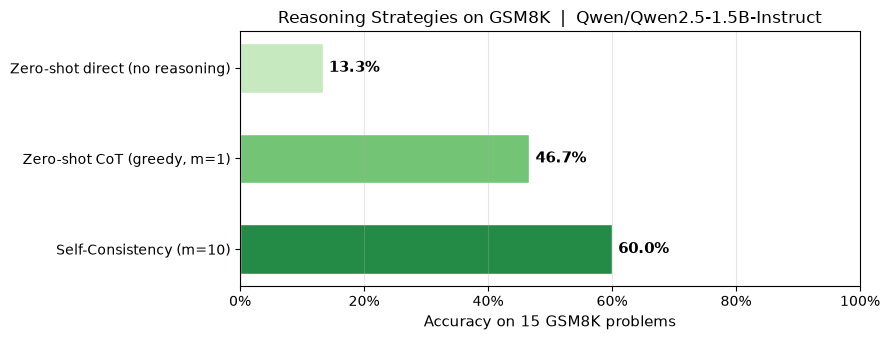


  Method                                    Acc  Notes
  Zero-shot direct (no reasoning)         13.3%  no CoT
  Zero-shot CoT (greedy, m=1)             46.7%  "Let's think step by step"
  Self-Consistency (m=10)                 60.0%  majority vote over sampled CoT paths


In [37]:
math_results = [
    ("Zero-shot direct (no reasoning)",      zero_shot_acc,         "no CoT"),
    ("Zero-shot CoT (greedy, m=1)",           cot_acc,               "\"Let's think step by step\""),
    (f"Self-Consistency (m={M_SAMPLES})",     self_consistency_acc,  "majority vote over sampled CoT paths"),
]

fig, ax = plt.subplots(figsize=(9, 3.5))
labels = [r[0] for r in math_results]
accs   = [r[1] for r in math_results]
colors = ["#c7e9c0", "#74c476", "#238b45"]
bars   = ax.barh(labels, accs, color=colors, edgecolor="white", height=0.55)

for bar, acc in zip(bars, accs):
    ax.text(acc + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{acc:.1%}", va="center", fontsize=11, fontweight="bold")

ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlabel(f"Accuracy on {N_TEST_MATH} GSM8K problems", fontsize=11)
ax.set_title(f"Reasoning Strategies on GSM8K  |  {COT_MODEL_ID}", fontsize=12)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 68)
print(f"  {'Method':<38} {'Acc':>6}  Notes")
print("=" * 68)
for name, acc, note in math_results:
    print(f"  {name:<38} {acc:>6.1%}  {note}")
print("=" * 68)